In [1]:
from pathlib import Path
import sys
import numpy as np
import yaml
from PIL import Image, ImageDraw, ImageFont

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.build import build_finetune_loader

config = yaml.safe_load((ROOT / 'config/finetune_test.yaml').read_text())
loader_config = dict(config['data']['train'])
loader_config['folders'] = [dict(folder, path=str(ROOT / folder['path'])) for folder in loader_config['folders']]
loader_config['batch_size'] = 2 * 2
loader_config['num_workers'] = 0
loader = build_finetune_loader(loader_config, train=True)
PROMPT_FONT = ImageFont.truetype('arial.ttf', 56)
TARGET_FONT = ImageFont.truetype('arial.ttf', 28)

def draw_input(batch, index):
    array = batch['image'][index].permute(1, 2, 0).numpy()
    image = Image.fromarray(np.clip((array + 1) * 127.5, 0, 255).astype('uint8'))
    prompt = batch['prompt'][index]
    if prompt['mask'] is not None:
        mask = Image.fromarray((prompt['mask'] * 255).astype('uint8')).resize(image.size)
        color = Image.new('RGB', image.size, (255, 0, 255))
        image = Image.composite(Image.blend(image, color, 0.35), image, mask)
    draw = ImageDraw.Draw(image)
    if prompt['points'] is not None:
        for (x, y), label in zip(prompt['points'], prompt['point_labels']):
            color = 'cyan' if label else 'orange'
            draw.ellipse((x - 10, y - 10, x + 10, y + 10), fill=color)
    if prompt['box'] is not None:
        draw.rectangle(tuple(prompt['box']), outline='cyan', width=5)
    draw.text((20, 20), f"prompt: {prompt['type']}", font=PROMPT_FONT, fill='white', stroke_width=4, stroke_fill='black')
    return image.resize((504, 504))

def draw_target(batch, index):
    label = batch['label_target'][index]
    name = 'background' if label[0] == 0 else ('frog' if label[1] == 1 else 'leaf')
    target = batch['target'][index, 0].numpy() * float(batch['mask_valid'][index])
    image = Image.fromarray((target * 255).astype('uint8')).convert('RGB')
    image = image.resize((504, 504), Image.Resampling.NEAREST)
    ImageDraw.Draw(image).text((10, 10), f'target: {name}', font=TARGET_FONT, fill='white', stroke_width=2, stroke_fill='black')
    return image


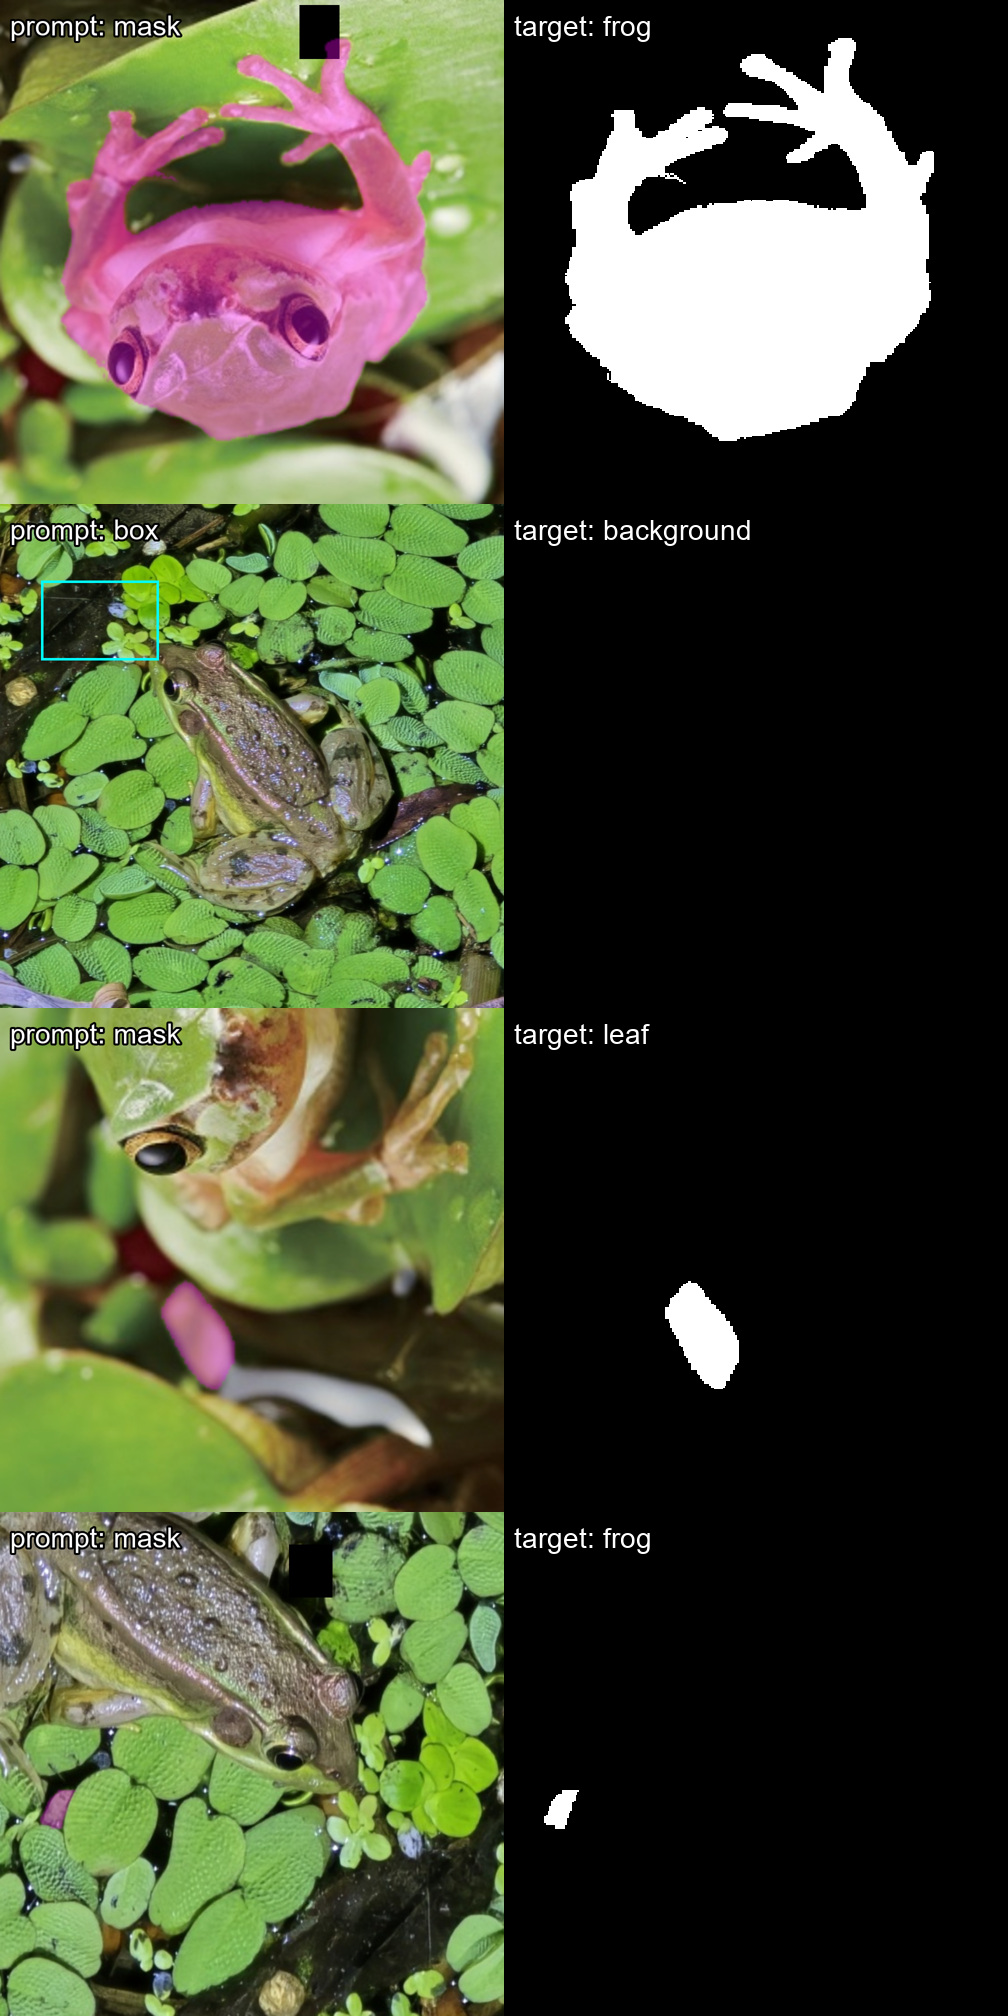

In [2]:
batch = next(loader)
sheet = Image.new('RGB', (1008, 504 * len(batch['image'])), 'white')
for index in range(len(batch['image'])):
    sheet.paste(draw_input(batch, index), (0, index * 504))
    sheet.paste(draw_target(batch, index), (504, index * 504))
sheet
